### Dataset Formation

In [1]:
import os
import torch
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class MyRatDataset(Dataset):
    """
    A dataset that reads images and YOLO-format annotations from a folder.
    Expected structure:
        root/
          images/
            img1.jpg
            img2.jpg
            ...
          labels/
            img1.txt
            img2.txt
            ...
    Each label file should contain lines (YOLO format):
        class_id  x_center_norm  y_center_norm  width_norm  height_norm
    Negative samples can be created on the fly with a given probability.
    This updated version prints a warning and ignores any image whose label file contains negative values.
    """
    def __init__(self, root, transforms=None, negative_sample_ratio=0.3):
        """
        Args:
            root (str): Path to the subset folder (e.g., 'new_dataset/train').
                        Must contain 'images/' and 'labels/' subfolders.
            transforms (callable, optional): Transformations to apply to the PIL image.
            negative_sample_ratio (float): The probability (0 to 1) of generating a negative sample from a positive image.
        """
        self.root = root
        self.transforms = transforms
        self.negative_sample_ratio = negative_sample_ratio
        
        self.img_dir = os.path.join(root, "images")
        self.lbl_dir = os.path.join(root, "labels")
        
        # Collect image file names
        self.imgs = [f for f in os.listdir(self.img_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        self.imgs.sort()  # for consistent ordering

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Load image
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Load annotations from the corresponding label file
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.lbl_dir, label_name)
        
        boxes = []
        labels = []
        corrupt = False  # flag for negative values in the label file
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    try:
                        class_id = int(parts[0]) + 1  # shift class indices if needed
                        x_center_norm = float(parts[1])
                        y_center_norm = float(parts[2])
                        width_norm    = float(parts[3])
                        height_norm   = float(parts[4])
                    except ValueError:
                        continue

                    # Check for negative values
                    if x_center_norm < 0 or y_center_norm < 0 or width_norm < 0 or height_norm < 0:
                        # print(f"WARNING {img_path}: ignoring corrupt image/label: negative label values "
                        #       f"[{x_center_norm:.5f}, {y_center_norm:.5f}, {width_norm:.5f}, {height_norm:.5f}]")
                        corrupt = True
                        break

                    # Convert normalized coords to absolute pixel coordinates
                    x_center = x_center_norm * w
                    y_center = y_center_norm * h
                    box_width = width_norm * w
                    box_height = height_norm * h
                    x_min = x_center - box_width / 2
                    y_min = y_center - box_height / 2
                    x_max = x_center + box_width / 2
                    y_max = y_center + box_height / 2
                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(class_id)
        
        # If corrupt, treat this image as a negative sample (no boxes)
        if corrupt:
            boxes = []
            labels = []

        # If no annotations, treat image as a negative sample naturally
        if len(boxes) == 0:
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        # Optionally generate a negative sample from a positive image
        if boxes.shape[0] > 0 and random.random() < self.negative_sample_ratio:
            img = self.generate_negative_sample(img, boxes)
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        
        image_id = torch.tensor([idx])
        if boxes.size(0) > 0:
            area = (boxes[:,2] - boxes[:,0]) * (boxes[:,3] - boxes[:,1])
        else:
            area = torch.empty((0,), dtype=torch.float32)
        iscrowd = torch.zeros((labels.shape[0],), dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
        
        if self.transforms:
            img = self.transforms(img)
        
        return img, target

    def generate_negative_sample(self, img, boxes):
        """
        Generate a negative sample by filling the regions of each bounding box in the image with random noise.
        Args:
            img (PIL.Image): The original image.
            boxes (Tensor): Tensor of shape [N, 4] with bounding box coordinates in absolute pixel values.
        Returns:
            PIL.Image: The image with the rat regions replaced with noise.
        """ 
        img_np = np.array(img)
        for box in boxes:
            x_min, y_min, x_max, y_max = box.int().tolist()
            x_min = max(0, x_min)
            y_min = max(0, y_min)
            x_max = min(img_np.shape[1], x_max)
            y_max = min(img_np.shape[0], y_max)
            if x_max > x_min and y_max > y_min:
                noise = np.random.randint(0, 256, (y_max - y_min, x_max - x_min, 3), dtype=np.uint8)
                img_np[y_min:y_max, x_min:x_max, :] = noise
        return Image.fromarray(img_np)

# Example usage:
if __name__ == "__main__":
    transforms = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    
    dataset_root = "new_dataset\\train"  # Folder with subfolders: images/ and labels/
    dataset = MyRatDataset(root=dataset_root, transforms=transforms, negative_sample_ratio=0.3)
    
    # Inspect a sample
    img, target = dataset[0]
    print("Sample target:", target)
    
    from torch.utils.data import DataLoader
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda batch: tuple(zip(*batch)))
    
    for images, targets in dataloader:
        print(f"Batch has {len(images)} images")
        for t in targets:
            print("Boxes:", t["boxes"], "Labels:", t["labels"])
        break


Sample target: {'boxes': tensor([[ 19.0000, 133.2500, 168.0000, 396.7500]]), 'labels': tensor([1]), 'image_id': tensor([0]), 'area': tensor([39261.5000]), 'iscrowd': tensor([0])}
Batch has 4 images
Boxes: tensor([[1.2400e+02, 2.5000e-01, 2.7600e+02, 3.0275e+02]]) Labels: tensor([1])
Boxes: tensor([[ 73.0000, 278.7500, 223.0000, 516.2500]]) Labels: tensor([1])
Boxes: tensor([], size=(0, 4)) Labels: tensor([], dtype=torch.int64)
Boxes: tensor([[ 84.0000, 114.0000, 223.0003, 180.0000],
        [ 77.0003,  57.0002, 221.0003, 115.0001],
        [189.0000, 383.9998, 322.0003, 439.9999]]) Labels: tensor([1, 1, 1])


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def show_negative_samples(dataset, dataset_name="Dataset"):
    print(f"\nShowing negative samples from: {dataset_name}")
    count = 0
    
    for i in range(len(dataset)):
        img, target = dataset[i]
        
        # Check if there are no bounding boxes (i.e., negative sample)
        if target["boxes"].numel() == 0:
            count += 1
            print(f"  Negative sample index: {i}, image file: {dataset.imgs[i]}")
            
            # Convert the tensor image to NumPy for display
            # If your dataset uses normalization, you may want to 'undo' it for visualization
            img_np = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
            
            # Optional: undo normalization for better display
            # mean = np.array([0.485, 0.456, 0.406])
            # std = np.array([0.229, 0.224, 0.225])
            # img_np = std * img_np + mean
            # img_np = np.clip(img_np, 0, 1)
            
            plt.figure(figsize=(6, 6))
            plt.imshow(img_np)
            plt.title(f"{dataset_name} Negative Sample idx={i}")
            plt.axis('off')
            plt.show()
    
    print(f"Found {count} negative samples in {dataset_name}.")


## Fine Tune Training

In [ ]:
import os
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchsummary import summary
from torch.cuda.amp import autocast, GradScaler
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from torch.optim.lr_scheduler import StepLR
import time

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Assume your custom dataset class MyRatDataset is defined elsewhere.
# It should return images (PIL Images) and targets (a dict with keys "boxes", "labels", etc.).
transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_dataset = MyRatDataset(root="fine_tune\\train", transforms=transforms, negative_sample_ratio=0.01)
val_dataset   = MyRatDataset(root="fine_tune\\valid", transforms=transforms, negative_sample_ratio=0.01)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda batch: tuple(zip(*batch))
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=lambda batch: tuple(zip(*batch))
)

# -----------------------------
# Load Model and Pretrained Weights
# -----------------------------
model = ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2,
    weights_backbone=torchvision.models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
)
device = torch.device("cuda:0")
model.to(device)

pth_path = "Model.pth"
if os.path.exists(pth_path):
    model.load_state_dict(torch.load(pth_path, map_location=device))
    print(f"Loaded pretrained weights from {pth_path}")

# -----------------------------
# Freeze Entire Backbone and Transform
# -----------------------------
# Freeze the backbone (feature extractor) and transform
for param in model.backbone.parameters():
    param.requires_grad = True
for param in model.transform.parameters():
    param.requires_grad = True
# DefaultBoxGenerator is typically not trainable, so no need to adjust it.

# -----------------------------
# Freeze Entire Detection Head
# -----------------------------
for param in model.head.parameters():
    param.requires_grad = True

# Optionally, freeze BatchNorm layers (this helps keep them stable)
def freeze_bn(module):
    if isinstance(module, torch.nn.BatchNorm2d):
        module.eval()
        for p in module.parameters():
            p.requires_grad = False
model.apply(freeze_bn)



# Optionally, print model summary.
summary(model, input_size=(3, 320, 320))

# -----------------------------
# Unfreeze Only the Final Two Blocks of the Detection Head
# -----------------------------
# The detection head consists of a classification head and a regression head,
# each with a ModuleList. Here we assume you want to unfreeze the last two blocks.
for i in [-2, -1]:
    for param in model.head.classification_head.module_list[i].parameters():
        param.requires_grad = True
    for param in model.head.regression_head.module_list[i].parameters():
        param.requires_grad = True

# Check number of trainable parameters
total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_trainable)

# -----------------------------
# Optimizer and Scheduler
# -----------------------------
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0001,
    weight_decay=0.0005
)
scheduler = StepLR(optimizer, step_size=2, gamma=0.1)

# -----------------------------
# Setup AMP and TensorBoard
# -----------------------------
scaler = GradScaler()
writer = SummaryWriter(log_dir=r"C:\Machine Learning\Rat Tracking using TensorFlow\runs")

num_epochs = 20
# -----------------------------
# Training and Validation Loop
# -----------------------------
train_losses = []
val_losses = []
train_cls_losses = []
val_cls_losses = []
train_bbox_losses = []
val_bbox_losses = []
start = time.time()
for epoch in range(num_epochs):
    model.train()
    model.apply(freeze_bn)  # Ensure BN layers remain frozen

    epoch_train_loss = 0.0
    epoch_train_cls_loss = 0.0
    epoch_train_bbox_loss = 0.0

    # Training Loop
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        filtered_images = []
        filtered_targets = []
        for img, tgt in zip(images, targets):
            if tgt["boxes"].numel() > 0:
                filtered_images.append(img)
                filtered_targets.append(tgt)

        optimizer.zero_grad()
        with autocast():
            if len(filtered_images) == 0:
                total_loss = torch.tensor(0., device=device, requires_grad=True)
            else:
                loss_dict = model(filtered_images, filtered_targets)
                cls_loss = loss_dict["classification"]
                bbox_loss = loss_dict["bbox_regression"]
                total_loss = cls_loss + bbox_loss

        if total_loss.item() != 0:
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

        epoch_train_loss += total_loss.item()
        if len(filtered_images) > 0:
            epoch_train_cls_loss += cls_loss.item()
            epoch_train_bbox_loss += bbox_loss.item()

    epoch_train_loss /= len(train_loader)
    epoch_train_cls_loss /= len(train_loader)
    epoch_train_bbox_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)
    train_cls_losses.append(epoch_train_cls_loss)
    train_bbox_losses.append(epoch_train_bbox_loss)

    writer.add_scalar("Loss/Train/Total", epoch_train_loss, epoch)
    writer.add_scalar("Loss/Train/Class", epoch_train_cls_loss, epoch)
    writer.add_scalar("Loss/Train/BBox", epoch_train_bbox_loss, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {epoch_train_loss:.4f}, "
          f"Cls Loss: {epoch_train_cls_loss:.4f}, BBox Loss: {epoch_train_bbox_loss:.4f}")

    # Validation Loop
    model.train()  # SSDLite returns losses only in train mode.
    model.apply(freeze_bn)
    epoch_val_loss = 0.0
    epoch_val_cls_loss = 0.0
    epoch_val_bbox_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            filtered_images = []
            filtered_targets = []
            for img, tgt in zip(images, targets):
                if tgt["boxes"].numel() > 0:
                    filtered_images.append(img)
                    filtered_targets.append(tgt)

            if len(filtered_images) == 0:
                total_loss = torch.tensor(0., device=device)
            else:
                loss_dict = model(filtered_images, filtered_targets)
                cls_loss = loss_dict["classification"]
                bbox_loss = loss_dict["bbox_regression"]
                total_loss = cls_loss + bbox_loss

            epoch_val_loss += total_loss.item()
            if len(filtered_images) > 0:
                epoch_val_cls_loss += cls_loss.item()
                epoch_val_bbox_loss += bbox_loss.item()

    epoch_val_loss /= len(val_loader)
    epoch_val_cls_loss /= len(val_loader)
    epoch_val_bbox_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    val_cls_losses.append(epoch_val_cls_loss)
    val_bbox_losses.append(epoch_val_bbox_loss)

    writer.add_scalar("Loss/Val/Total", epoch_val_loss, epoch)
    writer.add_scalar("Loss/Val/Class", epoch_val_cls_loss, epoch)
    writer.add_scalar("Loss/Val/BBox", epoch_val_bbox_loss, epoch)
    print(f"Epoch {epoch+1}/{num_epochs}: Val Loss: {epoch_val_loss:.4f}, "
          f"Cls Loss: {epoch_val_cls_loss:.4f}, BBox Loss: {epoch_val_bbox_loss:.4f}")

    # scheduler.step()
end = time.time() - start
# Save the fine-tuned model weights.
print(f"Training Time: {end}")
save_path = "Model_finetuned.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path:.2} secs")


C:\Users\mzarrar\AppData\Local\Temp\ipykernel_2676\1388591807.py:117: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Loaded pretrained weights from Model.pth
Layer (type:depth-idx)                             Param #
├─SSDLiteFeatureExtractorMobileNet: 1-1            --
|    └─Sequential: 2-1                             --
|    |    └─Sequential: 3-1                        (869,096)
|    |    └─Sequential: 3-2                        (2,102,856)
|    └─ModuleList: 2-2                             --
|    |    └─Sequential: 3-3                        (381,184)
|    |    └─Sequential: 3-4                        (100,480)
|    |    └─Sequential: 3-5                        (67,712)
|    |    └─Sequential: 3-6                        (25,664)
├─DefaultBoxGenerator: 1-2                         --
├─SSDLiteHead: 1-3                                 --
|    └─SSDLiteClassificationHead: 2-3              --
|    |    └─ModuleList: 3-7                        (64,104)
|    └─SSDLiteRegressionHead: 2-4                  --
|    |    └─ModuleList: 3-8                        (97,584)
├─GeneralizedRCNNTransform: 1-4     

Epoch 1/20:   0%|          | 0/3 [00:00<?, ?it/s]C:\Users\mzarrar\AppData\Local\Temp\ipykernel_2676\1388591807.py:152: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20: 100%|██████████| 3/3 [00:03<00:00,  1.31s/it]


Epoch 1/20: Train Loss: 5.2573, Cls Loss: 3.0614, BBox Loss: 2.1958
Epoch 1/20: Val Loss: 5.4975, Cls Loss: 3.0305, BBox Loss: 2.4669


Epoch 2/20: 100%|██████████| 3/3 [00:03<00:00,  1.25s/it]


...

Epoch 18/20: Train Loss: 3.6303, Cls Loss: 2.0429, BBox Loss: 1.5875
Epoch 18/20: Val Loss: 4.7628, Cls Loss: 2.4213, BBox Loss: 2.3415


Epoch 19/20: 100%|██████████| 3/3 [00:04<00:00,  1.34s/it]


Epoch 19/20: Train Loss: 3.1316, Cls Loss: 1.7673, BBox Loss: 1.3644
Epoch 19/20: Val Loss: 5.0510, Cls Loss: 2.4793, BBox Loss: 2.5717


Epoch 20/20: 100%|██████████| 3/3 [00:03<00:00,  1.27s/it]


Epoch 20/20: Train Loss: 3.7165, Cls Loss: 2.0114, BBox Loss: 1.7050
Epoch 20/20: Val Loss: 4.7405, Cls Loss: 2.3958, BBox Loss: 2.3446
Training Time: 109.47293663024902
Model saved to Mo secs


In [35]:
### PLot
import csv

# Save losses to a CSV file
csv_file = "fine_tuned_losses.csv"
with open(csv_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Train Loss", "Train cls Loss", "Train bbox Loss", "Val Loss", "Val cls Loss", "Val bbox Loss",])
    for epoch, t_loss, t_cls, t_bbox, v_loss, v_cls, v_bbox in zip(range(1, num_epochs + 1), train_losses, train_cls_losses, train_bbox_losses, val_losses, val_cls_losses, val_bbox_losses):
        writer.writerow([epoch, t_loss, t_cls, t_bbox, v_loss, v_cls, v_bbox])
print(f"Losses saved to {csv_file}")

Losses saved to fine_tuned_losses.csv


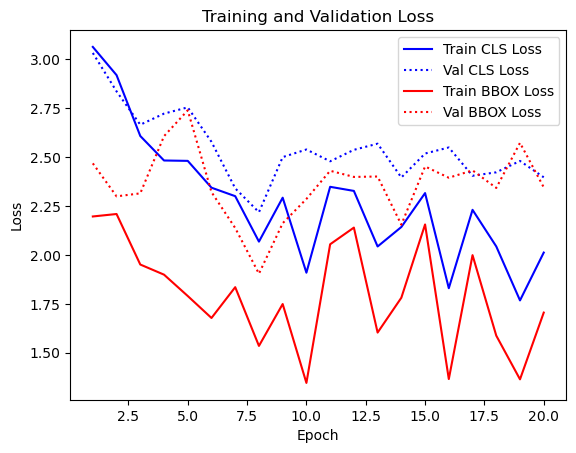

In [36]:
import csv
import matplotlib.pyplot as plt

epochs = []
train_cls_losses = []
val_cls_losses = []
train_bbox_losses = []
val_bbox_losses = []

# Load data from the CSV file
with open("fine_tuned_losses.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        epochs.append(int(row["Epoch"]))
        train_cls_losses.append(float(row["Train cls Loss"]))
        val_cls_losses.append(float(row["Val cls Loss"]))
        train_bbox_losses.append(float(row["Train bbox Loss"]))
        val_bbox_losses.append(float(row["Val bbox Loss"]))

# Plot the loss curves with consistent colors and line styles
cls_color = 'blue'
bbox_color = 'red'

plt.plot(epochs, train_cls_losses, color=cls_color, linestyle='-', label="Train CLS Loss")
plt.plot(epochs, val_cls_losses, color=cls_color, linestyle=':', label="Val CLS Loss")
plt.plot(epochs, train_bbox_losses, color=bbox_color, linestyle='-', label="Train BBOX Loss")
plt.plot(epochs, val_bbox_losses, color=bbox_color, linestyle=':', label="Val BBOX Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


### Video Detection

In [44]:
import cv2
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from PIL import Image
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights

# Define the transform (same as during training)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

device = torch.device("cuda")

# Load and modify the detection model
model = ssdlite320_mobilenet_v3_large(
    weights=None,
    num_classes=2
)
model.to(device)

# Load saved weights
model_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Model_finetuned.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

def predict(image_input, model, device, threshold=0.7, nms_threshold=0.3, top_k=1):
    """
    Predict detections on a given image.
    
    Args:
        image_input (str or np.ndarray): If string, treated as file path;
                                           if np.ndarray, treated as an OpenCV BGR image.
        model: The detection model.
        device: Computation device.
        threshold (float): Confidence threshold.
        nms_threshold (float): IoU threshold for non-maximum suppression.
        top_k (int): Number of top detections to display.
    
    Returns:
        orig_img (np.ndarray): The original image in BGR format.
        boxes (np.ndarray): Array of bounding boxes.
        scores (np.ndarray): Detection scores.
        labels (np.ndarray): Detected labels.
        inference_time_ms (float): Inference time in milliseconds.
    """
    # Check input type and convert accordingly
    if isinstance(image_input, np.ndarray):
        # image_input is a frame (BGR)
        pil_img = Image.fromarray(cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB))
        orig_img = image_input.copy()  # keep a copy in BGR for display
    elif isinstance(image_input, str):
        pil_img = Image.open(image_input).convert("RGB")
        orig_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    else:
        raise ValueError("Unsupported type for image_input. Must be str or np.ndarray.")
    
    # Apply transforms to create a tensor
    img_tensor = transform(pil_img).to(device)
    img_tensor = img_tensor.unsqueeze(0)  # add batch dimension

    # Measure inference time using OpenCV ticks
    start = cv2.getTickCount()
    with torch.no_grad():
        outputs = model(img_tensor)
    end = cv2.getTickCount()
    inference_time_ms = (end - start) / cv2.getTickFrequency() * 1000.0

    output = outputs[0]
    boxes = output['boxes'].cpu().numpy()
    scores = output['scores'].cpu().numpy()
    labels = output['labels'].cpu().numpy()

    # Filter out detections below confidence threshold
    keep = scores >= threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    if len(boxes) > 0:
        # Optionally, apply non-maximum suppression (NMS)
        if nms_threshold > 0:
            boxes_tensor = torch.tensor(boxes, device=device)
            scores_tensor = torch.tensor(scores, device=device)
            labels_tensor = torch.tensor(labels, device=device)
            keep_indices = torchvision.ops.nms(boxes_tensor, scores_tensor, nms_threshold)
            keep_indices = keep_indices.cpu().numpy()
            boxes = boxes_tensor[keep_indices].cpu().numpy()
            scores = scores_tensor[keep_indices].cpu().numpy()
            labels = labels_tensor[keep_indices].cpu().numpy()

        # Select top_k detections based on scores
        k = min(top_k, len(scores))
        sorted_indices = np.argsort(scores)[::-1][:k]
        boxes = boxes[sorted_indices]
        scores = scores[sorted_indices]
        labels = labels[sorted_indices]

    return orig_img, boxes, scores, labels, inference_time_ms

def main():
    # Choose one of your video files
    video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\3_Mice.mp4"
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\BaselineDark.mp4"
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\brown_rats.mp4"
    # video_path = r"C:\Machine Learning\Rat Tracking using TensorFlow\Video\TestFile_video.mp4"
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return

    frame_count = 0  # Initialize a frame counter

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1  # Increment the frame counter
        
        # Predict on the current frame
        orig_img, boxes, scores, labels, inf_time = predict(
            frame, model, device, threshold=0.2, nms_threshold=0.0, top_k=3)
        print("Labels:", labels)
        print("Inference time (ms):", inf_time)

        # Draw bounding boxes, label text, and centroid red dot on the frame
        for box, score, label in zip(boxes, scores, labels):
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(orig_img, f"Rat: {score:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            # Compute and draw the centroid as a red dot
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2
            cv2.circle(orig_img, (cx, cy), 3, (0, 0, 255), -1)
        
        # Draw inference time on the frame
        cv2.putText(orig_img, f"Inference: {inf_time:.1f} ms", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
        
        # Display the frame number (e.g., at the top left corner)
        cv2.putText(orig_img, f"Frame: {frame_count}", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)
        
        # Display the frame with predictions
        cv2.imshow("Predictions", orig_img)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()


Labels: [1 1 1]
Inference time (ms): 40.2996
Labels: [1 1 1]
Inference time (ms): 61.495599999999996
Labels: [1 1 1]
Inference time (ms): 33.4997
Labels: [1 1 1]
Inference time (ms): 50.9396
Labels: [1 1 1]
Inference time (ms): 35.2877
Labels: [1 1 1]
Inference time (ms): 25.816
Labels: [1 1 1]
Inference time (ms): 34.0075
Labels: [1 1 1]
Inference time (ms): 34.9409
Labels: [1 1 1]
Inference time (ms): 29.8381
Labels: [1 1 1]
Inference time (ms): 32.4998
Labels: [1 1 1]
Inference time (ms): 36.7421
Labels: [1 1 1]
Inference time (ms): 31.333
Labels: [1 1 1]
Inference time (ms): 36.4508
Labels: [1 1 1]
Inference time (ms): 23.3119
Labels: [1 1 1]
Inference time (ms): 26.6037
Labels: [1 1 1]
Inference time (ms): 41.2442
Labels: [1 1 1]
Inference time (ms): 32.836200000000005
Labels: [1 1 1]
Inference time (ms): 31.0978
Labels: [1 1 1]
Inference time (ms): 29.3101
Labels: [1 1 1]
Inference time (ms): 38.3311
Labels: [1 1 1]
Inference time (ms): 28.4996
Labels: [1 1 1]
Inference time (ms)